# 01 — EDA

Thin notebook (PLAN.md §6): loads the frozen `corpus_v1.parquet` (built by
T1.8) and produces the first two required EDA figures (PLAN.md §7,
Figure 1): the rating distribution and the review-length distribution.
These are also the "Understand the problem" evidence PLAN.md §3 E0 calls
for, and directly motivate why CRAGB (the benchmark, built later) needs
deliberately-sampled negative/low-star questions rather than relying on
the corpus's natural (heavily positive) rating skew.

This notebook contains no pipeline logic of its own — it reads the
already-built corpus and calls plotting code only.

In [1]:
import sys
sys.path.insert(0, "../src")

import matplotlib.pyplot as plt
import pandas as pd

from cragb.utils.io import load_config, resolve_path

cfg = load_config("configs/data.yaml")
corpus = pd.read_parquet(resolve_path(cfg["paths"]["corpus_out"]))
print(corpus.shape)
corpus[["rating", "token_len"]].describe()

(200000, 20)


,rating,token_len
count,200000.000000,200000.000000
mean,3.843815,64.595030
std,1.400586,77.215665
min,1.000000,1.000000
25%,3.000000,18.000000
50%,5.000000,41.000000
75%,5.000000,84.000000
max,5.000000,1914.000000


## Figure 1a — Rating distribution

`corpus_v1` is a *stratified* sample (T1.7), not the raw corpus — its
20/15/65 split across 1-2/3/4-5 star reviews is a deliberately engineered
property (Risk C in PLAN.md: plain random sampling would leave 1-2 star
"defect/fit" questions almost without evidence). This figure documents
what the frozen corpus actually contains, which is the sampled
distribution, not the raw source distribution.

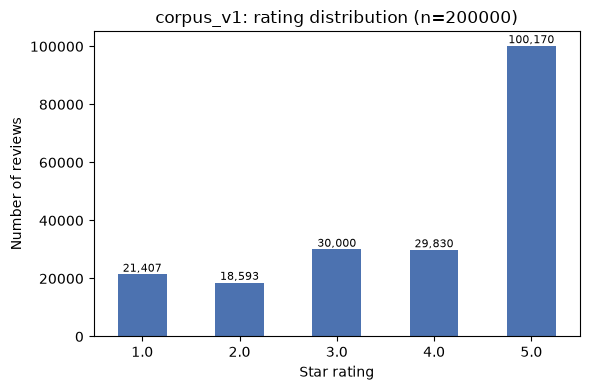

In [2]:
fig, ax = plt.subplots(figsize=(6, 4))
corpus["rating"].value_counts().sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Star rating")
ax.set_ylabel("Number of reviews")
ax.set_title("corpus_v1: rating distribution (n=%d)" % len(corpus))
ax.tick_params(axis="x", rotation=0)
for i, v in enumerate(corpus["rating"].value_counts().sort_index()):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom", fontsize=8)
fig.tight_layout()
fig.savefig("../reports/figures/eda_rating_dist.png", dpi=150)
plt.show()

## Figure 1b — Review-length distribution

Uses `token_len` (T1.6's regex-based token proxy, not an exact LLM
tokenizer — see `cragb.data.features` docstring for why that distinction
is deliberate at this stage). Plotted on a log-x axis: review length is
strongly right-skewed (many short reviews, a long tail of detailed ones),
so a linear axis would compress almost everything into one bar.

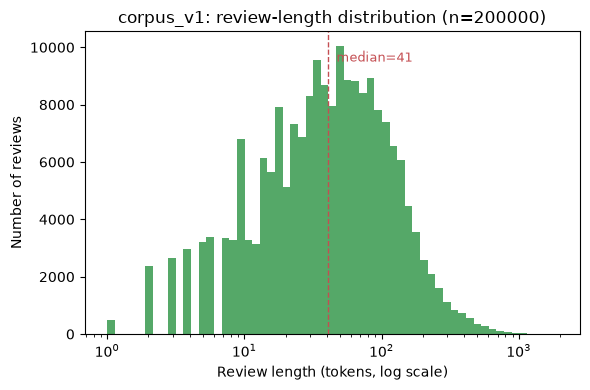

In [3]:
import numpy as np

fig, ax = plt.subplots(figsize=(6, 4))
# Log-spaced bins: with a log-x axis, linearly-spaced bins render as
# unequal (and misleading) bar widths. np.logspace keeps each bar's
# width visually proportional to its actual token-count range.
bins = np.logspace(0, np.log10(corpus["token_len"].max()), 60)
ax.hist(corpus["token_len"], bins=bins, color="#55A868")
ax.set_xscale("log")
ax.set_xlabel("Review length (tokens, log scale)")
ax.set_ylabel("Number of reviews")
ax.set_title("corpus_v1: review-length distribution (n=%d)" % len(corpus))
median = corpus["token_len"].median()
ax.axvline(median, color="#C44E52", linestyle="--", linewidth=1)
ax.text(median, ax.get_ylim()[1] * 0.9, f"  median={median:.0f}", color="#C44E52", fontsize=9)
fig.tight_layout()
fig.savefig("../reports/figures/eda_length_dist.png", dpi=150)
plt.show()

## Summary statistics (for the datasheet / report text)

In [4]:
summary = {
    "n_reviews": len(corpus),
    "rating_mean": round(corpus["rating"].mean(), 3),
    "rating_counts": corpus["rating"].value_counts().sort_index().to_dict(),
    "token_len_median": int(corpus["token_len"].median()),
    "token_len_mean": round(corpus["token_len"].mean(), 1),
    "token_len_p95": int(corpus["token_len"].quantile(0.95)),
    "token_len_max": int(corpus["token_len"].max()),
}
summary

{'n_reviews': 200000,
 'rating_mean': np.float64(3.844),
 'rating_counts': {1.0: 21407,
  2.0: 18593,
  3.0: 30000,
  4.0: 29830,
  5.0: 100170},
 'token_len_median': 41,
 'token_len_mean': np.float64(64.6),
 'token_len_p95': 195,
 'token_len_max': 1914}